|<img style="float:left;" src="../images/usherb_transp.gif" width=90% height=90%> |<big>Pierre Proulx, ing, professeur</big>|
|:---|:---|
|Département de génie chimique et de génie biotechnologique |** GCH200-Phénomènes d'échanges I **|



### Exercice 6A3

In [2]:
#
# Pierre Proulx
#
# Préparation de l'affichage et des outils de calcul symbolique
#
import sympy as sp
from IPython.display import *
import thermo as th
sp.init_printing(use_latex=True)
# Paramètres, variables et fonctions
rho,L,D,mu,Q,dP=sp.symbols('rho,L,D,mu,Q,dP')                                                            

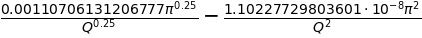

Reynolds 36124    et débit en gal/hr 4141    


In [3]:
f=1/4*(D/L)*(dP/((1/2)*rho*(Q/(sp.pi*D**2/4))**2))    # equation définissant le facteur f
Re=4*Q*rho/(sp.pi*mu*D)              # Reynolds avec le débit volumique au lieu de la vitesse                     
f_T=0.0791/Re**0.25                      # si Re > 2100 
# Dictionnaire contenant les valeurs des paramètres
# convertis en SI
LSI=1320*0.3048   # metres
densite=th.Chemical('water',273+20,101325).rhol
viscosite=th.Chemical('water',273+20,101325).mul
dico={'rho':densite,'D':6*0.0254,'mu':viscosite,'L':LSI,'dP':0.25*101325/14.7}
#
#  On a l'équation 6.1.4, définition de f, et 6.2-12 qui calcule f en fonction de Reynolds.
#   2 équations, 2 inconnues en fonction de f et de Q, on peut éliminer facilement f en posant les deux
#    équations égales, in le reste alors que Q  comme variable
#
eq=f_T-f    
eq=eq.subs(dico)
display(eq)
debit=sp.solve(eq,Q)
debitGal=debit[0]*951019
Reynolds=Re.subs(dico).subs(Q,debit[0]).evalf(6)
print('Reynolds {:<8.0f} et débit en gal/hr {:<8.0f}'.format(Reynolds,debitGal))